In [1]:
import numpy as np
import pandas as pd
import random as rd
import seaborn as sns
import matplotlib.pyplot as plt
from math import sqrt
from scipy.optimize import basinhopping, minimize
import time
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid", {'axes.grid' : False})
plt.rcParams['font.family'] = ['Microsoft YaHei','Arial']
plt.rcParams['axes.unicode_minus'] = False

In [10]:
import sympy as sp

# 定义符号变量
v, p1, u1, c = sp.symbols('v p1 u1 c')

# # 被积函数
# integrand = 1/(1-u1)**2 * (v - 2*u1 + 1) * (v - p1)

# # 计算定积分
# integral_result = sp.integrate(integrand, (v, p1, u1))
# print(integral_result)

integral_result = "(p1-c)*(1 - (p1-2*u1+1)**2/(2*(1-u1)**2)) + ((1 - u1)**3 + (p1 - u1)**3 + 3*(1 - u1)*(1 - p1)*(u1 - p1))/(6*(1 - u1)**2)"
# 化简
simplified = sp.simplify(integral_result)
print(simplified) 

(-3*(c - p1)*(2*(u1 - 1)**2 - (p1 - 2*u1 + 1)**2) - 3*(p1 - 1)*(p1 - u1)*(u1 - 1) + (p1 - u1)**3 - (u1 - 1)**3)/(6*(u1 - 1)**2)



    (c*p1**2/2 - 2*c*p1*u1 + c*p1 + c*u1**2 - c/2 - p1**3/3 + p1**2*u1 - p1**2/2 - u1**3/3 + 1/6)/(u1**2 - 2*u1 + 1)
   

     if c <= p1 <= 2*u1:
         if p1 <= u1:
             w1 = c*p1**2/(2*u1**2) - c - p1**3/(3*u1**2) + u1

         else:
             w1 = (p1 - 2*u1)**2*(-c/2 + p1/3 + u1/3)/u1**2
    if c <= p1 <= 1:
        if p1 >= 2*u1-1:
            if p1 <= u1:
                w1 = (-3*(c - p1)*(2*(u1 - 1)**2 - (p1 - 2*u1 + 1)**2) - 3*(p1 - 1)*(p1 - u1)*(u1 - 1) + (p1 - u1)**3 - (u1 - 1)**3)/(6*(u1 - 1)**2)
            else:
                w1 = (p1 - 1)**2*(-3*c + 2*p1 + 1)/(6*(u1 - 1)**2)
        else:
            w1 = u1 - c
    else:
        w1 = 0

     if c <= p1 <= 2*u1:
         if p1 <= u1:
             r1 = (p1-c)*(1 - p1**2/(2*u1**2))
         else:
             r1 = (p1-c)*(2*u1 - p1)**2/(2*u1**2)
    if c <= p1 <= 1:
        if p1 >= 2*u1-1:
            if p1 <= u1:
                r1 = (p1-c)*(1 - (p1-2*u1+1)**2/(2*(1-u1)**2))
            else:
                r1 = (p1-c)*(1-p1)**2/(2*(1-u1)**2)
        else:
            r1 = p1 - c
    else:
        r1 = 0

    p1**3/(6*u1**2) - p1/2 + u1/3 - p1/2 + 2*u1/3 == p1**3/(6*u1**2) - p1 + u1    
    -p1**3/(6*u1**2) + p1**2/u1 - 2*p1 + 4*u1/3 == (2*u1 - p1)**3/(6*u1**2)    

    (p1**3 - 6*p1**2*u1 + 3*p1**2 + 9*p1*u1**2 - 6*p1*u1 - 4*u1**3 + 3*u1**2)/(6*(u1**2 - 2*u1 + 1)) - p1/2 + u1/3 + 1/6  == (p1**3 - 6*p1**2*u1 + 3*p1**2 + 6*p1*u1**2 - 3*p1 - 2*u1**3 + 1)/(6*(u1**2 - 2*u1 + 1))    
    (-p1**3 + 3*p1**2 - 3*p1 + 1)/(6*(u1**2 - 2*u1 + 1)) == (1 - p1)**3/(6*(1 - u1)**2)    

In [3]:
# 定义目标函数 
eps = 1e-6

def objective(x):
    p1, p2 = x
    if c <= p1 and p1 <= u1:
        r1 = (p1-c)*(u1-p1)/(1-p1)
    else:
        r1 = 0
    if c <= p2 and p2 <= u2:
        r2 = (p2-c)*(u2-p2)/(1-p2)
    else:
        r2 = 0
    R = r1 + r2
    return -R - eps * (p2 - p1)  # 最大化加 -

# 约束条件
def constraint1(x):
    # p1 >= c
    return x[0] - c

def constraint2(x):
    # 1 >= p2
    return 1 - x[1]

def constraint3(x):
    # p2 >= p1 
    return x[1] - x[0]

def constraint4(x):
    # p2 - p1 <= delta
    return delta - (x[1] - x[0])

# 约束字典
constraints = [
    {'type': 'ineq', 'fun': constraint1},  # 默认>=0
    {'type': 'ineq', 'fun': constraint2},
    {'type': 'ineq', 'fun': constraint3},
    {'type': 'ineq', 'fun': constraint4}
]

# 3. 随Δ变化

In [4]:
## 0 ##
c  = 0.2
u1 = 0.6
u2 = 0.9

Profits = []
opt_p1 = []
opt_p2 = []

num = 300
deltas = np.linspace(start=0, stop=num/1000, num=num)
start = time.time()
print('正在进行实验……')

for i in range(num):
    delta = deltas[i]    #  delta = 0.5 * i / num + 0.001
    bounds = [(c, u2), (c, u2)]
    initial_guess = np.array([(c+u1)/2, (c+u2)/2])
#     result = minimize(objective, initial_guess, 
#              bounds=bounds, 
#              constraints=constraints, 
#              method='SLSQP',
#              tol=1e-12,           # 收敛容忍度
#              options={'ftol': 1e-12,  # 函数值变化的容忍度
#                       'eps': 1e-8,    # 有限差分步长
#                       'maxiter': 1000, # 最大迭代次数
#                       'disp': False}   # 显示优化过程信息
#             )
    result = basinhopping(objective, initial_guess, niter=100,
                     minimizer_kwargs={'method': 'SLSQP', 
                                     'bounds': bounds,
                                     'constraints': constraints,
                                     'options': {'ftol': 1e-8}})
    optimal_p1, optimal_p2 = result.x
    max_profit = -result.fun
    Profits.append(max_profit)
    opt_p1.append(optimal_p1)
    opt_p2.append(optimal_p2)
    
time_cost = time.time() - start
print(f'{num}次实验结束,用时:{time_cost:.2f}s')

正在进行实验……
400次实验结束,用时:290.52s


# 4. 三角分布

In [5]:
## 1 ## 定义目标函数（均匀分布）
def objective_triangular(x):
    p1, p2 = x
#     if c <= p1 <= 2*u1:
#         if p1 <= u1:
#             r1 = (p1-c)*(1 - p1**2/(2*u1**2))
#         else:
#             r1 = (p1-c)*(2*u1 - p1)**2/(2*u1**2)
    if c <= p1 <= 1:
        if p1 >= 2*u1-1:
            if p1 <= u1:
                r1 = (p1-c)*(1 - (p1-2*u1+1)**2/(2*(1-u1)**2))
            else:
                r1 = (p1-c)*(1-p1)**2/(2*(1-u1)**2)
        else:
            r1 = p1 - c
    else:
        r1 = 0
        
#     if c <= p2 <= 2*u2:
#         if p2 <= u2:
#             r2 = (p2-c)*(1 - p2**2/(2*u2**2))
#         else:
#             r2 = (p2-c)*(2*u2 - p2)**2/(2*u2**2)
    if c <= p2 <= 1:
        if p2 >= 2*u2-1:
            if p2 <= u2:
                r2 = (p2-c)*(1 - (p2-2*u2+1)**2/(2*(1-u2)**2))
            else:
                r2 = (p2-c)*(1-p2)**2/(2*(1-u2)**2)
        else:
            r2 = p2 - c
    else:
        r2 = 0
    return -(r1 + r2) - eps * (p2 - p1)  # 最大化加 -

def constraint1(x):
    # p1 >= c
    return x[0] - c

def constraint2(x):
    # 1 >= p2
    return 1 - x[1]

def constraint3(x):
    # p2 >= p1
    return x[1] - x[0]

def constraint4(x):
    # p2 - p1 <= delta
    return delta - (x[1] - x[0])

constraints = [
    {'type': 'ineq', 'fun': constraint1},  # 默认>=0
    {'type': 'ineq', 'fun': constraint2},
    {'type': 'ineq', 'fun': constraint3},
    {'type': 'ineq', 'fun': constraint4}
]

最优p1: 0.526599
最优p2: 0.816025
p之差: 0.289426
最大利润: 0.825848


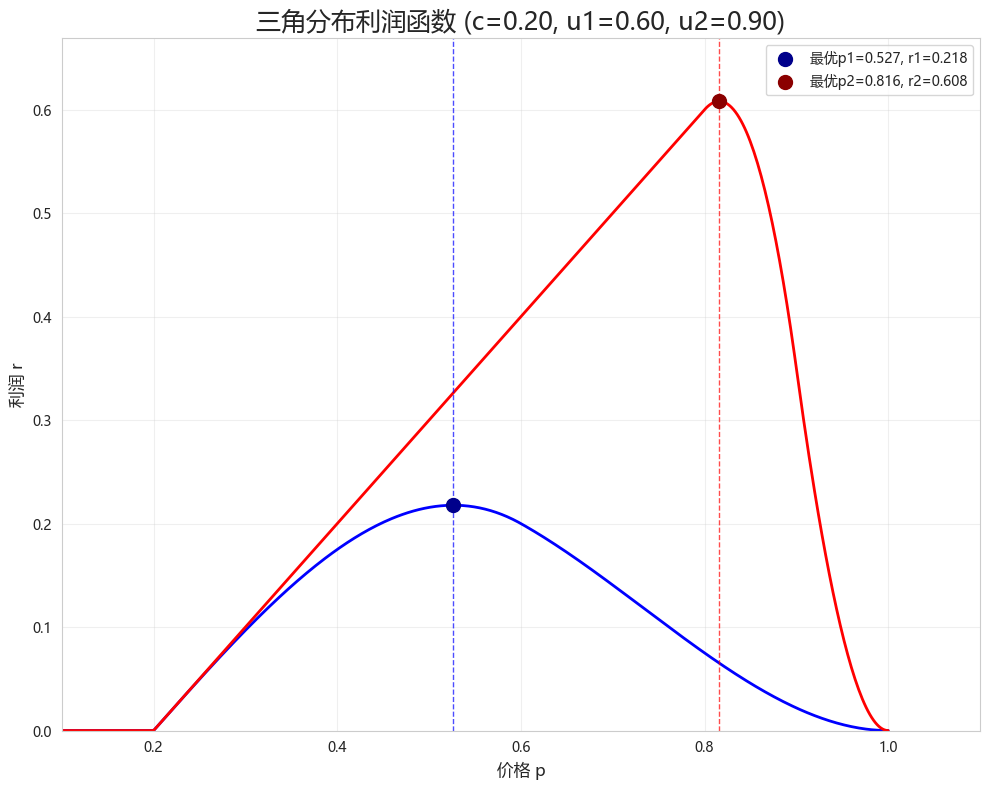

In [6]:
# 均匀分布利润函数
delta = 1 - c
bounds = [(c, 1), (c, 1)]
initial_guess = np.array([(c+2*u1)/2, (c+min(1,2*u2))/2])

result = minimize(objective_triangular, initial_guess, 
             bounds=bounds, 
             constraints=constraints, 
             method='SLSQP',
             tol=1e-12,           # 收敛容忍度
             options={'ftol': 1e-12,  # 函数值变化的容忍度
                      'eps': 1e-8,    # 有限差分步长
                      'maxiter': 1000, # 最大迭代次数
                      'disp': False}   # 显示优化过程信息
            )

optimal_p1, optimal_p2 = result.x
max_profit = -result.fun

print(f"最优p1: {optimal_p1:.6f}")
print(f"最优p2: {optimal_p2:.6f}")
print(f"p之差: {optimal_p2-optimal_p1:.6f}")
print(f"最大利润: {max_profit:.6f}")

plt.figure(figsize=(10, 8))
p_values = np.linspace(0, 1, 500)
r1_value = []
r2_value = []

## 2 ##
for p in p_values:
#     if c <= p <= 2*u1:
#         if p <= u1:
#             r1 = (p-c)*(1 - p**2/(2*u1**2))
#         else:
#             r1 = (p-c)*(2*u1 - p)**2/(2*u1**2)
    if c <= p <= 1:
        if p >= 2*u1-1:
            if p <= u1:
                r1 = (p-c)*(1 - (p-2*u1+1)**2/(2*(1-u1)**2))
            else:
                r1 = (p-c)*(1-p)**2/(2*(1-u1)**2)
        else:
            r1 = p - c
    else:
        r1 = 0
        
#     if c <= p <= 2*u2:
#         if p <= u2:
#             r2 = (p-c)*(1 - p**2/(2*u2**2))
#         else:
#             r2 = (p-c)*(2*u2 - p)**2/(2*u2**2)
    if c <= p <= 1:
        if p >= 2*u2-1:
            if p <= u2:
                r2 = (p-c)*(1 - (p-2*u2+1)**2/(2*(1-u2)**2))
            else:
                r2 = (p-c)*(1-p)**2/(2*(1-u2)**2)
        else:
            r2 = p - c
    else:
        r2 = 0
    r1_value.append(r1)
    r2_value.append(r2)

plt.plot(p_values, r1_value, linewidth=2, color='blue')  #, label=f'$r_1(p) = (p-{c:.1f})(1-p)/{2-2*u1:.1f}$'
plt.plot(p_values, r2_value, linewidth=2, color='red')  #, label=f'$r_2(p) = (p-{c:.1f})(1-p)/{2-2*u2:.1f}$'

## 3 ##
# if c <= optimal_p1 <= 2*u1:
#     if optimal_p1 <= u1:
#         optimal_r1 = (optimal_p1-c)*(1 - optimal_p1**2/(2*u1**2))
#     else:
#         optimal_r1 = (optimal_p1-c)*(2*u1 - optimal_p1)**2/(2*u1**2)
if c <= optimal_p1 <= 1:
    if optimal_p1 >= 2*u1-1:
        if optimal_p1 <= u1:
            optimal_r1 = (optimal_p1-c)*(1 - (optimal_p1-2*u1+1)**2/(2*(1-u1)**2))
        else:
            optimal_r1 = (optimal_p1-c)*(1-optimal_p1)**2/(2*(1-u1)**2)
    else:
        optimal_r1 = optimal_p1 - c
    
# if c <= optimal_p2 <= 2*u2:
#     if optimal_p2 <= u2:
#         optimal_r2 = (optimal_p2-c)*(1 - optimal_p2**2/(2*u2**2))
#     else:
#         optimal_r2 = (optimal_p2-c)*(2*u2 - optimal_p2)**2/(2*u2**2)
if c <= optimal_p2 <= 1:
    if optimal_p2 >= 2*u2-1:
        if optimal_p2 <= u2:
            optimal_r2 = (optimal_p2-c)*(1 - (optimal_p2-2*u2+1)**2/(2*(1-u2)**2))
        else:
            optimal_r2 = (optimal_p2-c)*(1-optimal_p2)**2/(2*(1-u2)**2)
    else:
        optimal_r2 = optimal_p2 - c

    
plt.scatter(optimal_p1, optimal_r1, s=100, color='darkblue', marker='o', 
           label=f'最优p1={optimal_p1:.3f}, r1={optimal_r1:.3f}', zorder=5)
plt.scatter(optimal_p2, optimal_r2, s=100, color='darkred', marker='o', 
           label=f'最优p2={optimal_p2:.3f}, r2={optimal_r2:.3f}', zorder=5)
plt.axvline(x=optimal_p1, color='blue', linestyle='--', alpha=0.7, linewidth=1)
plt.axvline(x=optimal_p2, color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.xlabel('价格 p', fontsize=12)
plt.ylabel('利润 r', fontsize=12)
plt.title(f'三角分布利润函数 (c={c:.2f}, u1={u1:.2f}, u2={u2:.2f})', fontsize=18)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0.5*c, 1.1)
plt.ylim(0, max(r2_value) * 1.1)
plt.tight_layout()
plt.show()

In [7]:
unif_p1 = []
unif_p2 = []

print('正在进行实验……')
for i in range(num):
    delta = deltas[i]
    bounds = [(c, 1), (c, 1)]
    initial_guess = np.array([(c+2*u1)/2, (c+min(1,2*u2))/2])
    result = minimize(objective_triangular, initial_guess, 
             bounds=bounds, 
             constraints=constraints, 
             method='SLSQP',
             tol=1e-12,               # 收敛容忍度
             options={'ftol': 1e-12,  # 函数值变化的容忍度
                      'eps': 1e-8,    # 有限差分步长
                      'maxiter': 1000,# 最大迭代次数
                      'disp': False}  # 显示优化过程信息
        )
    optimal_p1, optimal_p2 = result.x
    max_profit = -result.fun
    unif_p1.append(optimal_p1)
    unif_p2.append(optimal_p2)
print(f'{num}次实验结束')

正在进行实验……
400次实验结束


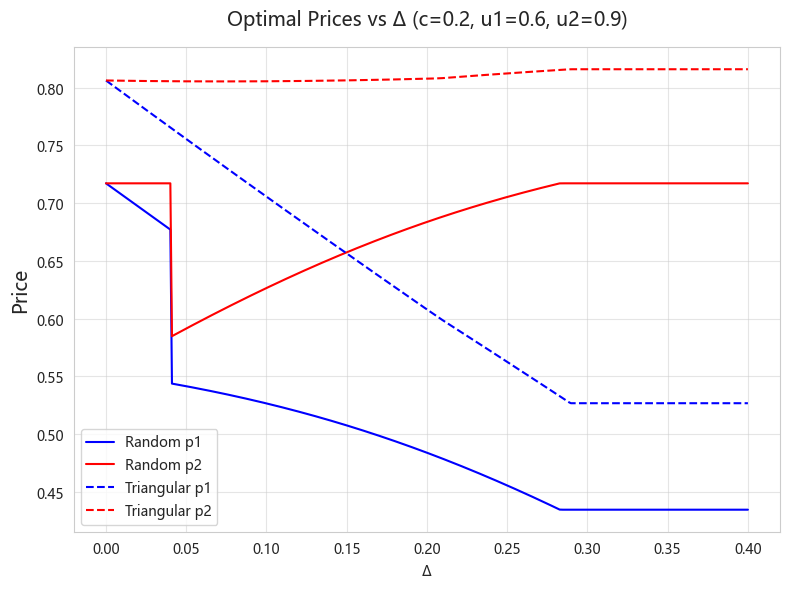

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(deltas, opt_p1, alpha=1, color="blue", label='Random p1')
plt.plot(deltas, opt_p2, alpha=1, color="red", label='Random p2')
plt.plot(deltas, unif_p1, alpha=1, color="blue", linestyle='--', label='Triangular p1')
plt.plot(deltas, unif_p2, alpha=1, color="red", linestyle='--', label='Triangular p2')
plt.title(f"Optimal Prices vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Price", fontsize=14)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
## 4 ## 
def cal_optimal_profit(p1, p2):
#     if c <= p1 <= 2*u1:
#         if p1 <= u1:
#             r1 = (p1-c)*(1 - p1**2/(2*u1**2))
#         else:
#             r1 = (p1-c)*(2*u1 - p1)**2/(2*u1**2)
    if c <= p1 <= 1:
        if p1 >= 2*u1-1:
            if p1 <= u1:
                r1 = (p1-c)*(1 - (p1-2*u1+1)**2/(2*(1-u1)**2))
            else:
                r1 = (p1-c)*(1-p1)**2/(2*(1-u1)**2)
        else:
            r1 = p1 - c
    else:
        r1 = 0
        
#     if c <= p2 <= 2*u2:
#         if p2 <= u2:
#             r2 = (p2-c)*(1 - p2**2/(2*u2**2))
#         else:
#             r2 = (p2-c)*(2*u2 - p2)**2/(2*u2**2)
    if c <= p2 <= 1:
        if p2 >= 2*u2-1:
            if p2 <= u2:
                r2 = (p2-c)*(1 - (p2-2*u2+1)**2/(2*(1-u2)**2))
            else:
                r2 = (p2-c)*(1-p2)**2/(2*(1-u2)**2)
        else:
            r2 = p2 - c
    else:
        r2 = 0
    return r1 + r2
    
    
def cal_optimal_surplus(p1, p2):
#     if c <= p1 <= 2*u1:
#         if p1 <= u1:
#             s1 = p1**3/(6*u1**2) - p1 + u1
#         else:
#             s1 = (2*u1 - p1)**3/(6*u1**2)
    if c <= p1 <= 1:
        if p1 >= 2*u1-1:
            if p1 <= u1:
                s1 = (p1**3 - 6*p1**2*u1 + 3*p1**2 + 6*p1*u1**2 - 3*p1 - 2*u1**3 + 1)/(6*(1 - u1)**2)
            else:
                s1 = (1 - p1)**3/(6*(1 - u1)**2)
        else:
            s1 = u1 - p1
    else:
        s1 = 0
        
#     if c <= p2 <= 2*u2:
#         if p2 <= u2:
#             s2 = p2**3/(6*u2**2) - p2 + u2
#         else:
#             s2 = (2*u2 - p2)**3/(6*u2**2)
    if c <= p2 <= 1:
        if p2 >= 2*u2-1:
            if p2 <= u2:
                s2 = (p2**3 - 6*p2**2*u2 + 3*p2**2 + 6*p2*u2**2 - 3*p2 - 2*u2**3 + 1)/(6*(1 - u1)**2)
            else:
                s2 = (1 - p2)**3/(6*(1 - u2)**2)
        else:
            s2 = u2 - p2
    else:
        s2 = 0
    return s1 + s2


In [10]:
Profits_robust = []
Profits_unif = []
Profits_ratio = []
Surplus_robust = []
Surplus_unif = []
Surplus_ratio = []
Welfare_robust = []
Welfare_unif = []
Welfare_ratio = []

# 将鲁棒解代入真实分布
for i in range(num):
    optimal_profit = cal_optimal_profit(opt_p1[i], opt_p2[i])
    optimal_surplus = cal_optimal_surplus(opt_p1[i], opt_p2[i])
    Profits_robust.append(optimal_profit)
    Surplus_robust.append(optimal_surplus)
    Welfare_robust.append(optimal_profit + optimal_surplus)
    
for i in range(num):
    optimal_profit = cal_optimal_profit(unif_p1[i], unif_p2[i])
    optimal_surplus = cal_optimal_surplus(unif_p1[i], unif_p2[i])
    Profits_unif.append(optimal_profit)
    Surplus_unif.append(optimal_surplus)
    Welfare_unif.append(optimal_profit + optimal_surplus)
    Surplus_ratio.append(Surplus_robust[i]/Surplus_unif[i])
    Profits_ratio.append(Profits_robust[i]/Profits_unif[i])
    Welfare_ratio.append(Welfare_robust[i]/Welfare_unif[i])

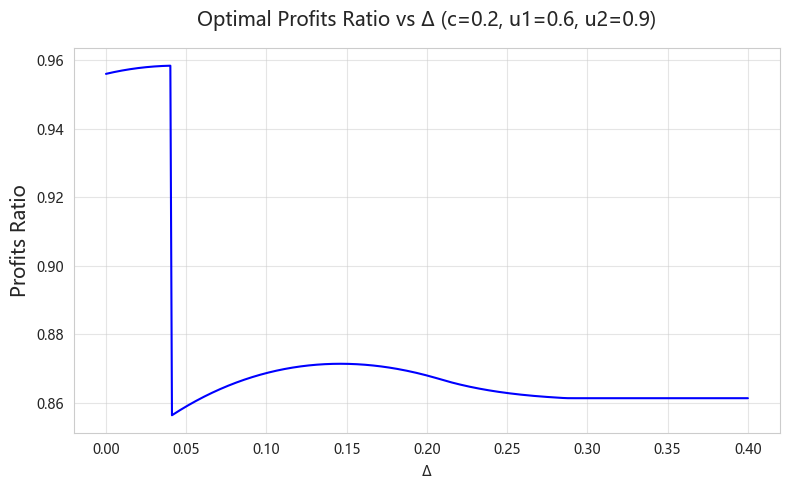

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Profits_ratio, alpha=1, color="blue")
plt.title(f"Optimal Profits Ratio vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Profits Ratio", fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

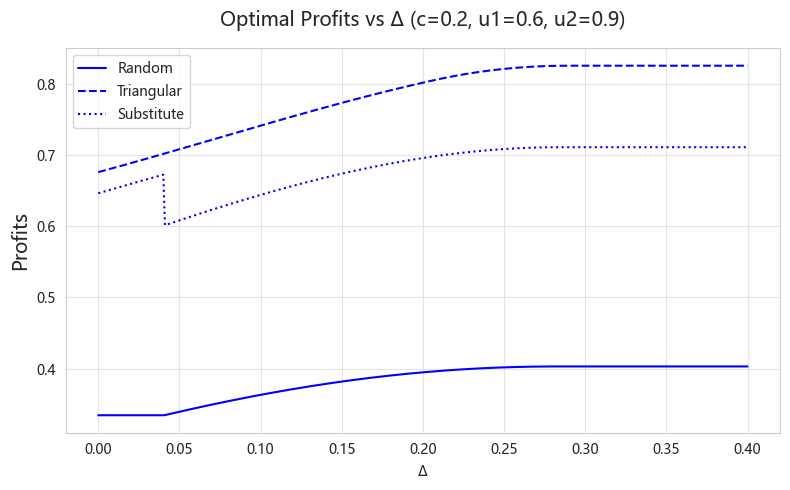

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Profits, alpha=1, color="blue", label="Random")
plt.plot(deltas, Profits_unif, alpha=1, color="blue", linestyle='--', label="Triangular")
plt.plot(deltas, Profits_robust, alpha=1, color="blue", linestyle=':', label="Substitute")
plt.title(f"Optimal Profits vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Profits", fontsize=14)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

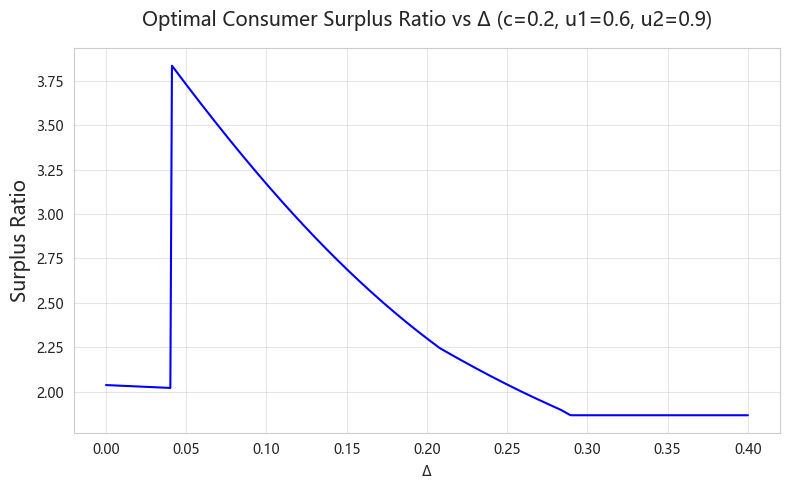

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Surplus_ratio, alpha=1, color="blue")
plt.title(f"Optimal Consumer Surplus Ratio vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Surplus Ratio", fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

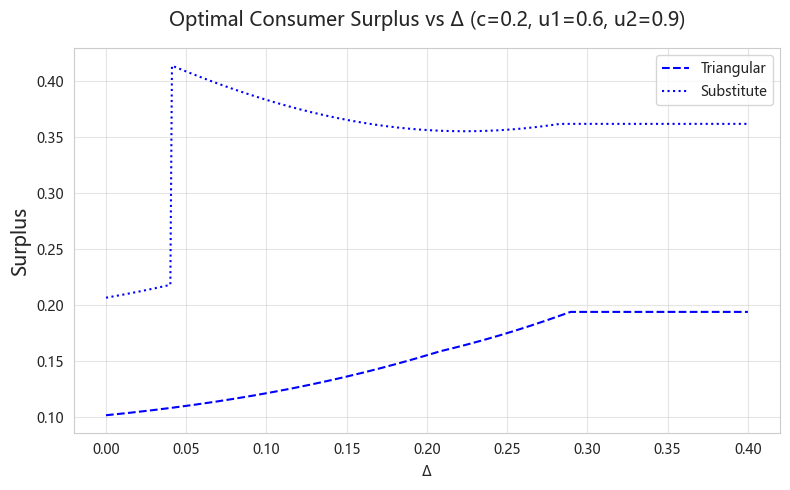

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Surplus_unif, alpha=1, color="blue", linestyle='--', label="Triangular")
plt.plot(deltas, Surplus_robust, alpha=1, color="blue", linestyle=':', label="Substitute")
plt.title(f"Optimal Consumer Surplus vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Surplus", fontsize=14)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

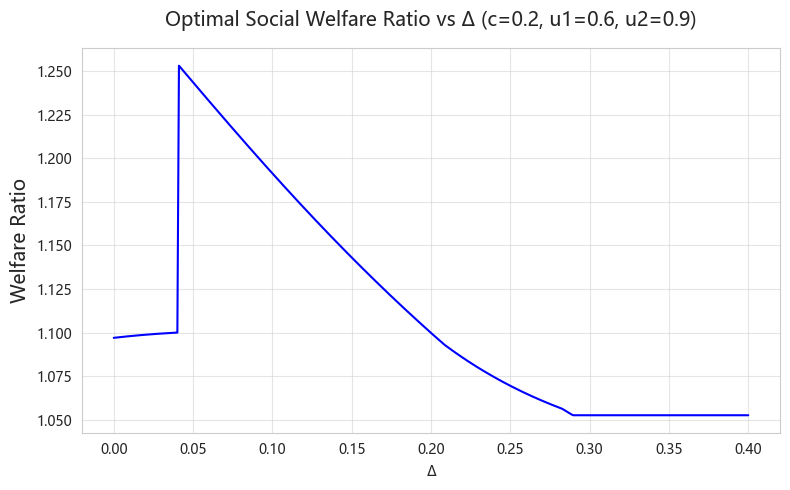

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Welfare_ratio, alpha=1, color="blue")
plt.title(f"Optimal Social Welfare Ratio vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Welfare Ratio", fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

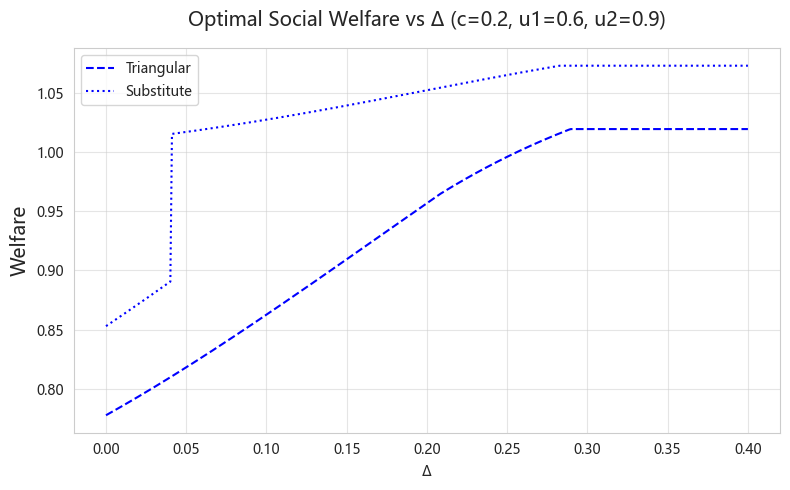

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Welfare_unif, alpha=1, color="blue", linestyle='--', label="Triangular")
plt.plot(deltas, Welfare_robust, alpha=1, color="blue", linestyle=':', label="Substitute")
plt.title(f"Optimal Social Welfare vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Welfare", fontsize=14)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 跳跃检验

In [17]:
# c =0.1
# u1=0.2
# u2=0.4

p = 1 - sqrt((1-c)*(2-u1-u2)/2)
const_1 = u1 - p
const_2 = -objective([p, p]) - (sqrt(1-c)-sqrt(1-u2))**2
# RT = sqrt(2 - 2*c - u1 + c*u1 - u2 + c*u2)
# const_2 = (2 - 2*c - sqrt(2)*RT) * (-2 + sqrt(2)*RT + u1 + u2) / (sqrt(2)*RT)  \
#          -(sqrt(1-c)-sqrt(1-u2))**2
const_3 = 1-(1-u1)**2/(1-c) - u2

print("c:",c,", u1:",u1,", u2:",u2) 
print(const_1, const_2)   # +  若都为正则不跳跃
print(const_3)            # -  若跳跃则必为负

c: 0.2 , u1: 0.6 , u2: 0.9
0.04721359549995785 -0.02316895705059374
-0.10000000000000009


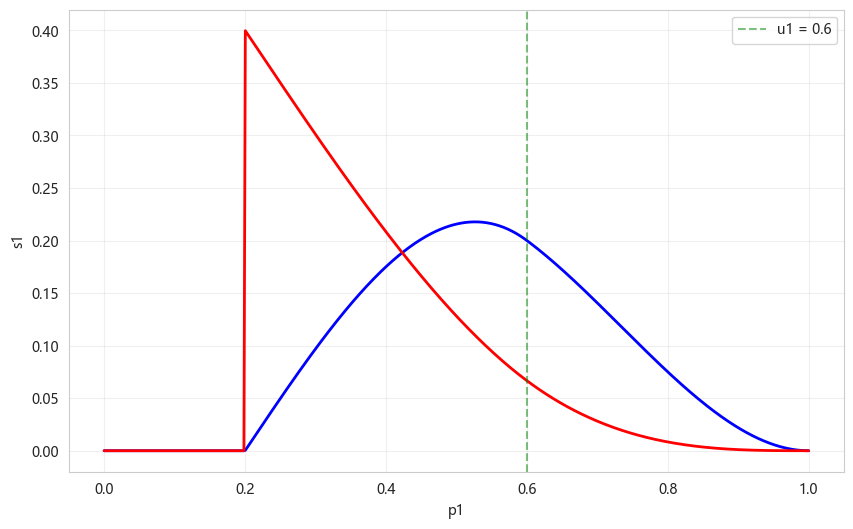

In [18]:
# def cal_profits_1(p1, u1):
#     if c <= p1 <= 1:
#         if p1 >= 2*u1-1:
#             if p1 <= u1:
#                 r1 = (p1-c)*(1 - (p1-2*u1+1)**2/(2*(1-u1)**2))
#             else:
#                 r1 = (p1-c)*(1-p1)**2/(2*(1-u1)**2)
#         else:
#             r1 = p1 - c
#     else:
#         r1 = 0
#     return r1
            
# def cal_surplus_2(p, u2):
#     if c <= p <= 1:
#         if p >= 2*u2-1:
#             if p <= u2:
#                 s2 = (p**3 - 6*p**2*u2 + 3*p**2 + 6*p*u2**2 - 3*p - 2*u2**3 + 1)/(6*(u2**2 - 2*u2 + 1))
#             else:
#                 s2 = (-p**3 + 3*p**2 - 3*p + 1)/(6*(u2**2 - 2*u2 + 1))
#         else:
#             s2 = u2 - p
#     else:
#         s2 = 0
#     return s2

# # 生成数据点
# p_values = np.linspace(0, 1, 500)
# s1_values = [cal_profits_1(p, u1) for p in p_values]
# s2_values = [cal_surplus_2(p, u1) for p in p_values]

# # 绘制图像
# plt.figure(figsize=(10, 6))
# plt.plot(p_values, s1_values, 'b-', linewidth=2, color="blue")
# plt.plot(p_values, s2_values, 'b-', linewidth=2, color="red")
# plt.axvline(x=u1, color='g', linestyle='--', alpha=0.5, label=f'u1 = {u1}')
# plt.xlabel('p1')
# plt.ylabel('s1')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.show()